In [1]:
import torch 
from torch.utils.data import Dataset, DataLoader
from pyteomics import mgf
import numpy as np
import logging
import torch.nn as nn
import torch
import torch.nn.functional as F
from torch import optim
import networkx as nx
from collections import deque
from matplotlib import pyplot as plt

from sklearn.metrics import (
    adjusted_mutual_info_score as AMI,
    adjusted_rand_score as ARI,
)
import random
import pandas as pd



In [11]:
# def get_bin_index(mz, min_mz, bin_size):
#     relative_mz = mz - min_mz
#     return max(0, int(np.floor(relative_mz / bin_size)))

# def bin_spectrum(mz_array, intensity_array, max_mz=2500, min_mz=50.5, bin_size=1.0005079):
#     """
#     bin spectrum and this algorithm reference from 'https://github.com/dhmay/param-medic/blob/master/parammedic/binning.pyx'
#     :param mz_array:
#     :param intensity_array:
#     :param max_mz:
#     :param min_mz:
#     :param bin_size:
#     :return:
#     """
#     nbins = int(float(max_mz - min_mz) / float(bin_size)) + 1
#     results = np.zeros(nbins)

#     for index in range(len(mz_array)):
#         mz = mz_array[index]
#         intensity = intensity_array[index]
#         intensity = np.sqrt(intensity)
#         if mz < min_mz or mz > max_mz:
#             continue
#         bin_index = get_bin_index(mz, min_mz, bin_size)

#         if bin_index < 0 or bin_index > nbins - 1:
#             continue
#         if results[bin_index] == 0:
#             results[bin_index] = intensity
#         else:
#             results[bin_index] += intensity

#     intensity_sum = results.sum()

#     if intensity_sum > 0:
#         results /= intensity_sum
#         # spectrum_dict[key] = results
#     else:
#         logging.debug('zero intensity found')
#     return results


# model input data preparation

In [16]:
# mgf_file_path = "./spectraList.mgf"    
# spectra = list(mgf.read(mgf_file_path))

processed_features = pd.read_hdf("./peptdeepwork/processed_features.h5", key="features")
processed_features


,0,1,2,3,4,5,6,7,8,9,...,47,48,49,50,51,52,53,54,55,56
18080635323514663207,-0.066837,1.242110,0.746972,-0.069704,-0.069538,-0.069381,-0.069236,-0.068794,-0.068469,-0.067082,...,-0.172200,2.558338,-0.627303,0.411093,-0.575519,-0.451568,0.0,1.414214,-0.707107,-0.707107
14669807044004538680,-0.066838,-0.170780,0.725590,-0.069411,-0.069283,-0.069105,-0.069019,-0.068531,-0.068232,-0.066787,...,2.475728,0.805907,2.464574,0.843902,2.549063,1.464245,0.0,1.414214,-0.707107,-0.707107
584780176198780664,-0.068232,-0.312673,-0.937530,-0.069779,-0.069715,-0.069576,-0.069496,-0.069076,-0.068841,-0.067493,...,-0.630078,2.273397,0.485894,-0.611832,-0.575519,-0.451568,0.0,-0.707107,-0.707107,1.414214
584780176198780663,-0.067843,-0.312673,-0.633082,-0.069779,-0.069715,-0.069576,-0.069496,-0.069076,-0.068701,-0.067345,...,-0.630078,0.393660,-0.627303,-0.570494,-0.575519,-0.451568,0.0,-0.707107,1.414214,-0.707107
584780176198780662,-0.067066,-0.312673,0.364587,-0.069723,-0.069717,-0.069561,-0.069465,-0.068970,-0.068701,-0.067233,...,0.254574,-0.630680,-0.627303,-0.088796,-0.392081,-0.451568,0.0,1.414214,-0.707107,-0.707107
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13956871899653124234,-0.066274,1.248301,0.661997,-0.069714,-0.069602,-0.069369,-0.069210,-0.068717,-0.068419,-0.066961,...,-0.331678,-0.522545,-0.440432,1.165769,1.806516,1.052303,0.0,-0.707107,-0.707107,1.414214
16568467721864459869,-0.063709,1.233154,2.434768,-0.067235,-0.067186,-0.067747,-0.067718,-0.067297,-0.067027,-0.065604,...,-0.630078,-0.630680,-0.627303,0.240429,2.568486,-0.451568,0.0,1.414214,-0.707107,-0.707107
16568467721864459870,-0.065605,1.233154,1.378530,-0.067235,-0.067186,-0.067642,-0.067580,-0.067176,-0.066908,-0.065476,...,-0.630078,-0.630680,-0.627303,2.642928,0.706135,-0.451568,0.0,-0.707107,1.414214,-0.707107
17256412178792009832,-0.063746,0.607052,2.259991,-0.067126,-0.067182,-0.067089,-0.067027,-0.066736,-0.066571,-0.065088,...,2.441639,2.558338,2.448579,2.565412,2.497366,3.718322,0.0,1.414214,-0.707107,-0.707107


In [17]:
# import pandas as pd
from sklearn.preprocessing import MinMaxScaler


# Apply Min-Max Scaling
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(processed_features)

# Convert back to DataFrame if needed
normalized_df = pd.DataFrame(normalized_data, columns=processed_features.columns)
normalized_df


,0,1,2,3,4,5,6,7,8,9,...,47,48,49,50,51,52,53,54,55,56
0,0.000114,0.911099,0.492208,0.000070,0.000072,0.000067,0.000068,0.000065,0.000065,0.000060,...,0.145572,1.000000,0.000000,0.314286,0.000000,0.000000,0.0,1.0,0.0,0.0
1,0.000114,0.461883,0.488509,0.000090,0.000090,0.000086,0.000083,0.000083,0.000081,0.000079,...,0.987423,0.450479,0.982555,0.447263,0.993822,0.451014,0.0,1.0,0.0,0.0
2,0.000041,0.416769,0.200823,0.000064,0.000060,0.000054,0.000050,0.000045,0.000039,0.000033,...,0.000000,0.910649,0.353758,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.0
3,0.000061,0.416769,0.253486,0.000064,0.000060,0.000054,0.000050,0.000045,0.000049,0.000043,...,0.000000,0.321209,0.000000,0.012700,0.000000,0.000000,0.0,0.0,1.0,0.0
4,0.000102,0.416769,0.426063,0.000068,0.000060,0.000055,0.000052,0.000053,0.000049,0.000050,...,0.281256,0.000000,0.000000,0.160699,0.058345,0.000000,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641908,0.000143,0.913068,0.477509,0.000069,0.000068,0.000068,0.000070,0.000070,0.000068,0.000068,...,0.094870,0.033909,0.059385,0.546154,0.757643,0.354036,0.0,0.0,0.0,1.0
641909,0.000277,0.908251,0.784163,0.000240,0.000235,0.000180,0.000173,0.000167,0.000162,0.000155,...,0.000000,0.000000,0.000000,0.261851,1.000000,0.000000,0.0,1.0,0.0,0.0
641910,0.000178,0.908251,0.601455,0.000240,0.000235,0.000187,0.000182,0.000175,0.000170,0.000163,...,0.000000,0.000000,0.000000,1.000000,0.407650,0.000000,0.0,0.0,1.0,0.0
641911,0.000275,0.709188,0.753930,0.000248,0.000235,0.000225,0.000220,0.000205,0.000193,0.000188,...,0.976585,1.000000,0.977472,0.976184,0.977379,0.981660,0.0,1.0,0.0,0.0


Get a sample of the normalized data

In [138]:
sample_size = 1000
sample_df = normalized_df.head(sample_size)
sample_df

,0,1,2,3,4,5,6,7,8,9,...,47,48,49,50,51,52,53,54,55,56
0,0.000114,0.911099,0.492208,0.000070,0.000072,0.000067,0.000068,0.000065,0.000065,0.000060,...,0.145572,1.000000,0.000000,0.314286,0.000000,0.000000,0.0,1.0,0.0,0.0
1,0.000114,0.461883,0.488509,0.000090,0.000090,0.000086,0.000083,0.000083,0.000081,0.000079,...,0.987423,0.450479,0.982555,0.447263,0.993822,0.451014,0.0,1.0,0.0,0.0
2,0.000041,0.416769,0.200823,0.000064,0.000060,0.000054,0.000050,0.000045,0.000039,0.000033,...,0.000000,0.910649,0.353758,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.0
3,0.000061,0.416769,0.253486,0.000064,0.000060,0.000054,0.000050,0.000045,0.000049,0.000043,...,0.000000,0.321209,0.000000,0.012700,0.000000,0.000000,0.0,0.0,1.0,0.0
4,0.000102,0.416769,0.426063,0.000068,0.000060,0.000055,0.000052,0.000053,0.000049,0.000050,...,0.281256,0.000000,0.000000,0.160699,0.058345,0.000000,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.000052,0.284687,0.268048,0.000066,0.000065,0.000064,0.000066,0.000062,0.000063,0.000061,...,0.449812,0.987858,0.455285,0.454356,0.965872,0.435510,0.0,0.0,1.0,0.0
996,0.000087,0.284687,0.417315,0.000066,0.000065,0.000064,0.000060,0.000060,0.000060,0.000056,...,0.998377,0.448512,0.445231,0.982807,0.443072,0.448450,0.0,1.0,0.0,0.0
997,0.000054,0.461480,0.271373,0.000088,0.000081,0.000074,0.000067,0.000060,0.000064,0.000057,...,0.000000,0.175668,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.0
998,0.000079,0.461480,0.335969,0.000099,0.000096,0.000095,0.000086,0.000079,0.000073,0.000065,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,1.0,0.0


In [15]:
# traning_spectrum_data = []
# for spectrum in normalized_df:
#     # seperate to bins and
#     # quantized_spectra =bin_spectrum(spectrum["m/z array"], spectrum["intensity array"])
#     # traning_spectrum_data.append(quantized_spectra)
#     print(spectrum)
#     break
    

## Ploting 3d 

In [135]:
def plot_tsne_results(tsne_df, size_multiplier=10, figsize=(12, 8)):
    """
    Visualizes t-SNE results with cluster coloring support and automatic dimensionality handling.
    
    Args:
        tsne_df (pd.DataFrame): DataFrame containing t-SNE coordinates (columns TSNE1, TSNE2...)
        size_multiplier (float): Scaling factor for 4th dimension visualization
        figsize (tuple): Figure size dimensions
    
    Returns:
        matplotlib.figure.Figure: The generated figure object
    """
    # Validate input columns
    tsne_cols = [col for col in tsne_df.columns if col.startswith('TSNE')]
    if not tsne_cols:
        raise ValueError("DataFrame must contain TSNE1, TSNE2... columns")
    
    n_components = len(tsne_cols)
    if n_components not in [2, 3, 4]:
        raise ValueError("Only 2D, 3D, or 4D t-SNE projections are supported")

    # Configure plot settings
    fig = plt.figure(figsize=figsize)
    color_by_cluster = 'cluster' in tsne_df.columns
    cmap = 'viridis' if color_by_cluster else None
    colors = tsne_df['cluster'] if color_by_cluster else None

    # Create appropriate axis
    if n_components >= 3:
        ax = fig.add_subplot(111, projection='3d')
    else:
        ax = fig.gca()

    # Get data for plotting
    xs = tsne_df['TSNE1']
    ys = tsne_df['TSNE2']
    zs = tsne_df['TSNE3'] if n_components >= 3 else None
    
    # Additional parameters
    kwargs = {'alpha': 0.7}
    if colors is not None:
        kwargs['c'] = colors
        kwargs['cmap'] = cmap
    
    if n_components == 4:
        # Normalize and scale TSNE4 for point sizes
        sizes = (tsne_df['TSNE4'] - tsne_df['TSNE4'].min()) * size_multiplier
        kwargs['s'] = sizes
    
    # Create scatter plot based on dimensions
    if n_components >= 3:
        sc = ax.scatter(xs, ys, zs, **kwargs)
    else:
        sc = ax.scatter(xs, ys, **kwargs)

    # Add labels and decorations
    ax.set_xlabel('TSNE1')
    ax.set_ylabel('TSNE2')
    if n_components >= 3:
        ax.set_zlabel('TSNE3')
    
    title = f"{n_components}D t-SNE Projection"
    if color_by_cluster:
        title += " (Colored by Cluster)"
    if n_components == 4:
        title += " (Size = TSNE4)"
    plt.title(title)

    # Add colorbar if using clusters
    if color_by_cluster:
        plt.colorbar(sc, label='Cluster', ax=ax)
    
    # Add legend for size if using 4D
    if n_components == 4:
        size_info = f"Size scale: {size_multiplier}x normalized TSNE4"
        plt.legend(*sc.legend_elements(prop='sizes'), title=size_info)

    plt.grid(True)
    return fig


to find similar vectors need to reduce the dimensions using tsne


In [130]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=4, 
    method='exact',
    learning_rate='auto',
    random_state=43, 
    perplexity=30,  #perplexity must be less than n_samples
    n_iter=1000,
    )
tsneResult = tsne.fit_transform(sample_df)
tsne_result=pd.DataFrame(tsneResult,columns=['TSNE1','TSNE2','TSNE3',"TSNE4"])

# tsne = TSNE(n_components=2, random_state=42)
# tsne_result = tsne.fit_transform(sample_df.drop(columns=['cluster']))

# from mpl_toolkits.mplot3d import Axes3D

# fig = plt.figure(figsize=(12, 8))
# ax = fig.add_subplot(111, projection='3d')

# # change the size multiplyer to make the points bigger or smaller
# size_multiplier =10
# sc = ax.scatter(
#     tsne_result['TSNE1'], 
#     tsne_result['TSNE2'],
#     tsne_result['TSNE3'],
#     # c=cluster_labels,
#     cmap='viridis',
#     s=tsne_result['TSNE4'] * size_multiplier  # Encode 4th dimension as size
# )
# plt.colorbar(sc)
# plt.title("4D t-SNE Projection (3D Plot + Size Encoding)")
# plt.show()



d:\FYP\specctraX\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


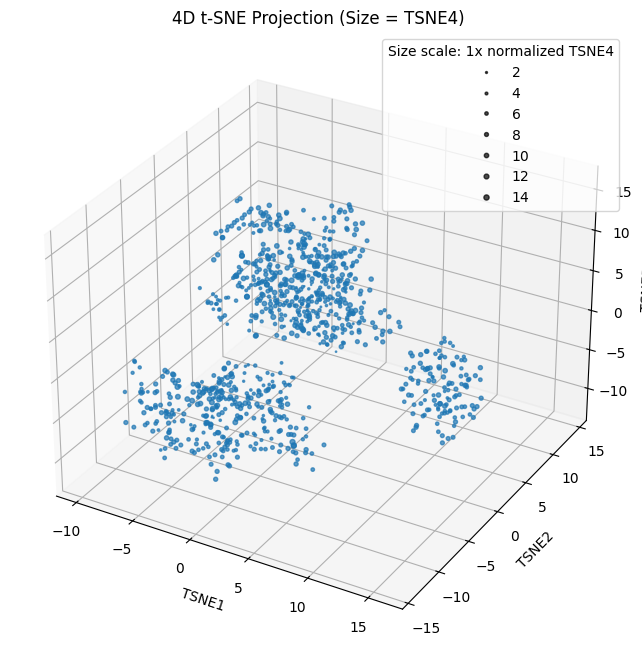

In [137]:
tsne_plot_df = tsne_result  # Add cluster column if exists
plot_tsne_results(tsne_plot_df, size_multiplier=1)
plt.show()

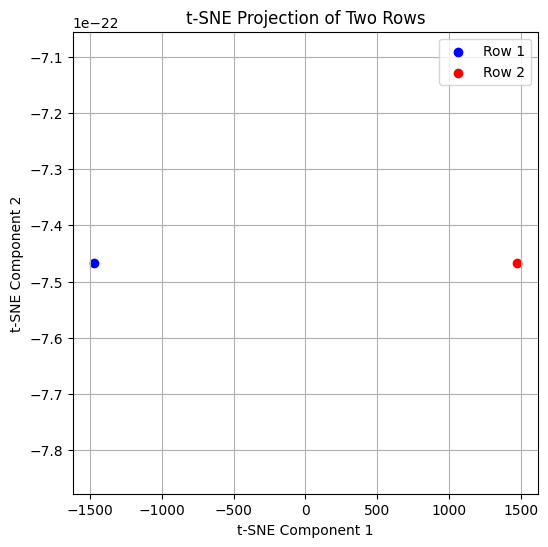

{'reduced_coordinates': array([[-1.4735293e+03, -7.4665541e-22],
       [ 1.4735293e+03, -7.4665541e-22]], dtype=float32), 'distance': 2.0909929554947366, 'similarity': 'Non-Similar'}


In [68]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def tsne_and_similarity(row1, row2, similarity_threshold=0.1):
    """
    Reduces two rows to 2D using t-SNE, plots them, and calculates their similarity.
    
    Args:
        row1 (list): First row of data.
        row2 (list): Second row of data.
        similarity_threshold (float): Threshold for determining similarity.

    Returns:
        dict: A dictionary containing reduced coordinates, distance, and similarity status.
    """
    # Combine the two rows into a single dataset
    data = np.array([row1, row2])

    # Apply t-SNE to reduce dimensions to 2
    tsne = TSNE(n_components=2, method='exact', random_state=42, perplexity=1)
    reduced_data = tsne.fit_transform(data)

    # Plot the two points with different colors
    plt.figure(figsize=(6, 6))
    plt.scatter(reduced_data[0, 0], reduced_data[0, 1], color='blue', label='Row 1')
    plt.scatter(reduced_data[1, 0], reduced_data[1, 1], color='red', label='Row 2')
    plt.legend()
    plt.title('t-SNE Projection of Two Rows')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.grid(True)
    plt.show()

    # Calculate Euclidean distance between the original rows
    distance = np.linalg.norm(np.array(row1) - np.array(row2))

    # Determine similarity based on the threshold
    similarity = 'Similar' if distance < similarity_threshold else 'Non-Similar'

    return {
        "reduced_coordinates": reduced_data,
        "distance": distance,
        "similarity": similarity
    }

# Example usage
row1 = sample_df.iloc[3] 
row2 = sample_df.iloc[2] 

result = tsne_and_similarity(row1, row2)
print(result)


Creating the DBScan


In [82]:
class DBSCANBase:
    def __init__(self, eps, minPts):
        self._eps = eps
        self._minPts = minPts

    def fit(self, X):
        pass

    def score(self, X, y):
        y_pred = self.predict(X)
        return (AMI(y, y_pred), ARI(y, y_pred))

    def predict(self, X):
        pass

In [83]:
class DBSCANGraphBased(DBSCANBase):
    
    def __init__(self, eps, minPts):
        super().__init__(eps, minPts)
    def fit(self, X):
        self._construct_graph(X)
        self._get_clusters()
        self._get_centroids(X)
        self._cluster_outliers(X)

    def predict(self, X):
        y = []
        for x in X:
            distances = {
                label: self._distance(x, centroid)
                for label, centroid in self._centroids.items()
            }
            y.append(min(distances, key=distances.get))
        return y

    def _construct_graph(self, X):
        cardinality = len(X)
        graph = nx.Graph()
        graph.add_nodes_from(
            list(range(cardinality)), is_core=False, visited=False, cluster=None
        )
        for i in range(cardinality):
            for j in range(i + 1, cardinality):
                if self._distance(X[i], X[j]) < self._eps:
                    graph.add_edge(i, j)
            if graph.degree[i] >= self._minPts:
                graph.nodes[i]["is_core"] = True
        self._graph = graph

    def _get_clusters(self):
        cluster_label = 0
        for node in self._graph:
            if not self._graph.nodes[node]["visited"] and self._graph.nodes[node][
                "is_core"
            ]:
                self._graph.nodes[node]["visited"] = True
                self._graph.nodes[node]["cluster"] = cluster_label
                self._bfs_node(node, cluster_label)
                cluster_label += 1
        self._num_clusters = cluster_label

    def _bfs_node(self, source, cluster_label):
        neighbors = self._graph.neighbors
        queue = deque([(source, len(self._graph), neighbors(source))])
        while queue:
            _, depth_now, children = queue[0]
            try:
                child = next(children)
                if not self._graph.nodes[child]["visited"]:
                    self._graph.nodes[child]["visited"] = True
                    self._graph.nodes[child]["cluster"] = cluster_label
                    if depth_now > 1:
                        queue.append((child, depth_now - 1, neighbors(child)))
            except StopIteration:
                queue.popleft()

    def _get_centroids(self, X):
        self._centroids = {}
        for i in range(self._num_clusters):
            X_list = []
            for node in self._graph:
                if self._graph.nodes[node]["cluster"] == i:
                    X_list.append(X[i])
            self._centroids.update({i: np.mean(X_list, axis=0)})

    def _cluster_outliers(self, X):
        for node in self._graph:
            if self._graph.nodes[node]["cluster"] is None:
                self._graph.nodes[node]["cluster"] = self.predict(X[node])

    @staticmethod
    def _distance(p1, p2):
        return np.linalg.norm(p1 - p2)


In [84]:
# normalized_df.isnull()

normalized_df = normalized_df.dropna()  # Remove rows with NaN values
normalized_df.shape

(594273, 57)

In [9]:
# sample_df.shape

In [169]:
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN

# Apply DBSCAN clustering
dbscan = DBSCAN(eps=1, min_samples=5)  # Tune `eps` and `min_samples`

cluster_labels = dbscan.fit_predict(normalized_df.head(1000))

cluster_labels

# # Add cluster labels to the DataFrame
# sample_df['cluster'] = cluster_labels

# # Display DataFrame with clusters
# print(sample_df.head())


array([-1, -1, -1, -1, -1,  0,  1, -1,  0,  1,  2,  0,  1,  3,  0,  1,  2,
        0, -1,  4,  0, -1, -1,  0,  1,  5, -1, -1, -1,  1, -1, -1, -1, -1,
        0,  1,  7, -1,  1,  2,  0,  1,  0, -1,  1, -1,  0,  1, -1, -1, -1,
        2,  0,  1,  5,  0, -1,  1, -1,  0,  1, -1,  0,  1, -1,  0, -1,  6,
        0, -1, -1,  0,  1, -1, 16,  1, -1,  0,  1,  7,  0,  1,  8, -1, -1,
       -1, -1,  1,  0,  1, -1,  0,  1, -1,  0, -1, -1,  0,  1, 18,  0, -1,
        1,  0,  1, -1,  0,  1, -1,  0,  1, -1,  0,  1, -1,  2,  0, -1, -1,
       -1, -1, -1,  0,  1, -1,  0,  1,  2,  0, -1,  7, -1,  1,  6,  0, -1,
        6, -1, -1,  6,  0, -1,  9, -1, -1,  1,  0, -1,  0, 10, -1,  0,  1,
       -1, -1,  1, -1, -1,  1, -1,  1, -1, -1, -1,  1, -1,  0,  1,  4,  0,
        1,  3,  0,  1, -1, -1,  0, -1,  5, 16, -1, -1,  0,  1, -1,  0,  1,
       -1, -1,  1, -1, 11,  1, 12, -1,  1, 11,  0,  1,  5,  0,  1, -1, -1,
       -1,  4, -1,  1, -1,  0, -1, -1,  0, -1, -1, -1, -1, -1, -1,  1,  8,
       -1,  1, -1,  0, 13

In [170]:

cluster_counts = pd.Series(cluster_labels).value_counts()
print(cluster_counts)
len(cluster_counts)


-1     384
 0     238
 1     207
 8      24
 6      21
 2      19
 7      17
 4      13
 16     10
 14     10
 10      7
 17      7
 3       6
 9       6
 15      6
 5       5
 18      5
 11      5
 12      5
 13      5
Name: count, dtype: int64


20

In [171]:
tsne_result_with_cluster_labels = tsne_result.copy()
tsne_result_with_cluster_labels['cluster'] = cluster_labels
tsne_result_with_cluster_labels

,TSNE1,TSNE2,TSNE3,TSNE4,cluster
0,2.018282,-1.642956,12.300784,-3.410275,-1
1,10.692527,-0.455805,-0.473175,-1.885076,-1
2,-1.029831,-11.775258,-4.258162,-2.331064,-1
3,-7.567507,8.612859,-1.283412,-3.039049,-1
4,5.879243,-1.314000,11.006499,-1.664845,-1
...,...,...,...,...,...
995,10.338001,4.785557,-0.559853,-0.248075,-1
996,14.655066,-1.344170,-3.833854,-1.408846,-1
997,-2.954973,-5.996945,-2.321271,-3.432008,0
998,-7.216646,-0.150754,1.406729,-2.482620,17


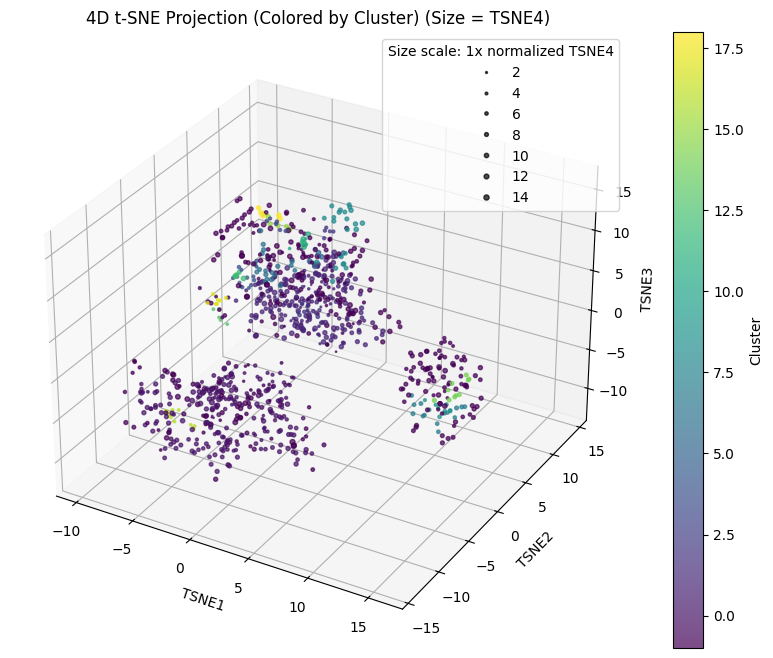

In [173]:

plot_tsne_results(tsne_result_with_cluster_labels, size_multiplier=1)
plt.show()

In [ ]:
# calibrant_mz = 622.034552
# ppm_error = 50
# calibrant_low_mz = calibrant_mz / (1 + ppm_error / 10**6)
# calibrant_high_mz = calibrant_mz * (1 + ppm_error / 10**6)
# df = data[:, :, :, calibrant_low_mz:calibrant_high_mz]

fig = scatter_plot(
    normalized_data,
)

fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [19]:
from sklearn.manifold import TSNE



tsne = TSNE(
    n_components=3, 
    learning_rate='auto',
    random_state=43, 
    perplexity=30,  #perplexity must be less than n_samples
    n_iter=1000,
    )
tsneResult = tsne.fit_transform(sample_df.drop(columns=['cluster']))
tsneDf=pd.DataFrame(tsneResult,columns=['TSNE1','TSNE2','TSNE3'])

# tsne = TSNE(n_components=2, random_state=42)
# tsne_result = tsne.fit_transform(sample_df.drop(columns=['cluster']))

tsne = TSNE( learning_rate=50 )
tsne_result = tsne.fit_transform(sample_df.drop(columns=['cluster']).head(10))

plt.figure(figsize=(10, 6))
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=cluster_labels, cmap='viridis', alpha=0.6)
plt.colorbar(label="Cluster Label")
plt.title("DBSCAN Clustering (t-SNE Projection)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()


NameError: name 'sample_df' is not defined

In [ ]:
traning_spectrum_data = np.array(normalized_df)
clusterer = DBSCANGraphBased(0.4, 5)
clusterer.fit(traning_spectrum_data)
# ami, ari = clusterer.score(X, y)
# print(f'AMI: {ami}, ARI: {ari}')
y_pred = clusterer.predict(traning_spectrum_data)
best_centroids = np.array(
    [centroid for centroid in clusterer._centroids.values()]
)

plt.scatter(traning_spectrum_data[:,0], traning_spectrum_data[:,1], c=y_pred);
plt.scatter(best_centroids[:,0], best_centroids[:,1], marker='x', color='red');


KeyboardInterrupt: 

In [ ]:
def pari_pectrum(spectra, label):
    spectra_count = len(spectra)
    labeled_spectral_pairs =[]
    for i in range(spectra_count):
        index1 = random.randint(0,spectra_count)
        index2 = random.randint(0,spectra_count)
        # if (label[index1]== label[index2]):
        #     is_same_label = True
        # else:
        #     is_same_label = False
        # labeled_spectral_pairs.append([spectra[index1], spectra[index2],is_same_label])
    # return labeled_spectral_pairs

pari_pectrum(traning_spectrum_data, y_pred)

# Loading the deconvoluted spectra using a dataloader

In [ ]:
class SpectrumDataset(Dataset):
    def __init__(self,mgf_file_path, max_peaks=200):
        self.mgf_file_path = mgf_file_path
        self.max_peaks = max_peaks
        self.spectra = list(mgf.read(mgf_file_path))
        
    def __len__(self):
        return len(self.spectra)

    def __getitem__(self, index):
        spectrum = self.spectra[index]
        mz_values = spectrum.get("m/z array", np.array([]))
        intensity_values = spectrum.get("intensity array", np.array([]))
        
        # normalize intensities
        intensity_values = intensity_values / np.max(intensity_values) if intensity_values.size else intensity_values

        return torch.tensor(np.stack(mz_values,intensity_values), axis=1)

    

In [ ]:
mgf_file_path = "./spectraList.mgf"
spectrum = list(mgf.read(mgf_file_path))    

In [ ]:
list(spectrum)[1].get("m/z array")

In [ ]:
mgf_file_path = "./spectraList.mgf"


dataset = SpectrumDataset(mgf_file_path)

Training_data_loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=1 )


In [ ]:
class SiamesNetwork(nn.Module):
    def __init__(self):
        super(SiamesNetwork, self).__init__()
        
        self.fc1 = nn.Sequential(
            nn.Linear(34,32),
            nn.SELU(),
            nn.Linear(32,5),
            nn.SELU()            
        )
        self.cnn11 = nn.Sequential(
            nn.Conv1d(1,30,3),
            nn.SELU(),
            nn.MaxPool1d(2),
            nn.SELU()
        )
        self.cnn21 = nn.Sequential(
            nn.Conv1d(1,30,3),
            nn.SELU(),
            nn.MaxPool1d(2),
            nn.SELU(),
            nn.Conv1d(30,30,3),
            nn.MaxPool1d(2),
            nn.SELU()
        )
        self.fc2 =nn.Linear(25775,32)
    
    def forward_once(self, x):
        # Get feature embeddings
        output = self.fc1(x)
        output = self.cnn11(x)
        output = self.cnn21(x)
        output = self.fc2(x)
        
        # Compute Euclidean distance
        return output
    
    def forward(self, x1, x2):
        output1 = self.forward_once(x1)
        output2 = self.forward_once(x2)
        return output1, output2

In [ ]:
# Define the Contrastive Loss Function
class ContrastiveLoss(torch.nn.Module):
    def __init__(self, margin=2.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
      # Calculate the euclidian distance and calculate the contrastive loss
      euclidean_distance = F.pairwise_distance(output1, output2, keepdim = True)

      loss_contrastive = torch.mean((1-label) * torch.pow(euclidean_distance, 2) +
                                    (label) * torch.pow(torch.clamp(self.margin - euclidean_distance, min=0.0), 2))


      return loss_contrastive

In [ ]:
net =SiamesNetwork()
lossFunc = ContrastiveLoss()
optimzer = optim.Adam(net.parameters(), lr = 0.0005)

In [ ]:
epoches = 10

for epoch in range(0, epoches):
    for i, data in enumerate(Training_data_loader,0):
        spectrum1, spectrum2, label = data
        optimzer.zero_grad()
        output1, output2 = net(spectrum1, spectrum2)
        loss_constrastive = lossFunc(output1, clear_output, label)
        loss_constrastive.backward()
        optimzer.step()
        
        if i % 10 == 0:
            print(f"Epoch {epoch+1}/{100}, Iteration {i}, Loss: {loss_constrastive.item()}")
 
        